In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
df = df[df.metric == metric]
df = df[~df.subj_id.isin(controls)]

region = ['CST']
regions = [f'{region[0]}_R', f'{region[0]}_L']
df = df[df.Object.isin(regions)]

/localscratch/tmp/ipykernel_5593/2891482668.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')


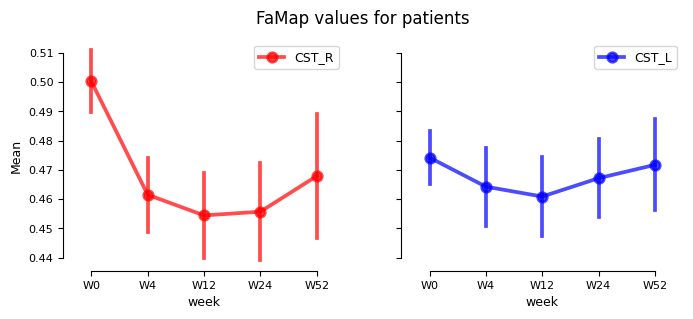

In [2]:
fig, axs = plt.subplots(1, 2, figsize = (8,3), constrained_layout = False, sharey = True, sharex = True)
sns.pointplot(x = 'week', y = 'Mean', data = df[df['Object'] == regions[0]], alpha = .7, label = regions[0], color = 'r', estimator = 'mean', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Mean', data = df[df['Object'] == regions[1]], alpha = .7, label = regions[1], color = 'b', estimator = 'mean', ax = axs[1], errorbar = 'se')


plt.suptitle(f"{metric} values for patients")
plt.legend()
sns.despine(trim = True)
plt.show()

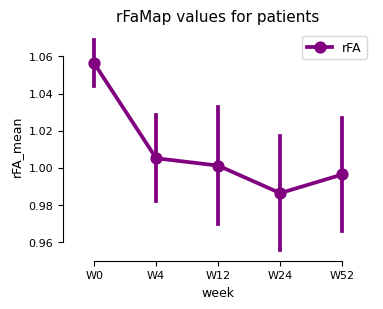

In [3]:
pivot_df = df.pivot_table(index = 'Image', columns = 'Object', values = 'Mean')
df['rFA_mean'] = df['Image'].map(pivot_df[f'{region[0]}_R'] / pivot_df[f'{region[0]}_L'])

fig, ax = plt.subplots(figsize = (4,3))
sns.pointplot(x = 'week', y = 'rFA_mean', data = df, label = 'rFA', color = 'purple', errorbar = 'se')


plt.title(f"r{metric} values for patients")
plt.legend()
sns.despine(trim = True)
plt.show()